# Predicción de Zona de Destino — NYC Yellow Taxi 2015-01

**Tarea 1 — Sistemas Urbanos Inteligentes (ICT3115, 2026-1)**  
**Problema:** Clasificación multiclase — predecir la zona de destino (`DOLocationID`, 265 clases)  
**Features:** tiempo de pickup + zona de origen (PULocationID) + metadata Census ACS del barrio de origen  
**Autores:** Nicolás Herrera y Vincent Metzker

> **Nota:** todas las features usadas son información disponible en el momento del pickup.

Este notebook cubre:
1. Carga de datos y preparación
2. MLP base (sin embeddings)
3. MLP con embeddings (PULocationID como embedding)
4. Análisis de sobreajuste + regularización
5. AutoEncoder + MLP
6. Análisis crítico final

## 0. Setup

In [16]:
import random, math, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             classification_report, confusion_matrix,
                             top_k_accuracy_score)
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

In [17]:
SEED = 22041991

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed()

if torch.cuda.is_available():   DEVICE = 'cuda'
elif torch.backends.mps.is_available(): DEVICE = 'mps'
else:                           DEVICE = 'cpu'

print('Dispositivo:', DEVICE)
DATA_DIR = '../data'

Dispositivo: cpu


## 1. Carga y preparación de datos

### 1.1 Cargar muestra

In [18]:
df = pd.read_parquet(os.path.join(DATA_DIR, 'trips_sample_with_cats.parquet'))
print(f'Shape cargado: {df.shape}')
df.head(3)

Shape cargado: (300000, 48)


,trip_distance,fare_amount,total_amount,tip_amount,tolls_amount,passenger_count,hour_sin,hour_cos,dow_sin,dow_cos,PU_Population,PU_MedianHouseholdIncome,PU_HousingUnits,PU_Transport_CarAlone_pct,PU_Transport_Carpool_pct,PU_Transport_PublicTransit_pct,PU_Transport_Walked_pct,PU_Transport_Bicycle_pct,PU_Transport_Other_pct,PU_Transport_WorkFromHome_pct,DO_Population,DO_MedianHouseholdIncome,DO_HousingUnits,DO_Transport_CarAlone_pct,DO_Transport_Carpool_pct,DO_Transport_PublicTransit_pct,DO_Transport_Walked_pct,DO_Transport_Bicycle_pct,DO_Transport_Other_pct,DO_Transport_WorkFromHome_pct,VendorID,RatecodeID,payment_type,store_and_fwd_flag,PULocationID,DOLocationID,PU_Borough_id,DO_Borough_id,hour,day_of_week,month,day_of_month,is_weekend,is_rush_hour,is_night,is_morning,is_afternoon,trip_duration
0,1.14,8.6,14.35,0.00,0.0,1.0,0.707107,0.707107,0.433884,-0.900969,1694251.0,106403.0,932314.0,5.2,1.1,51.0,18.3,3.1,3.2,18.1,1694251.0,106403.0,932314.0,5.2,1.1,51.0,18.3,3.1,3.2,18.1,2,1,2,0,161,50,0,0,3,3,1,15,0,0,1,0,0,6.133333
1,0.70,5.3,12.95,0.00,0.0,1.0,0.258819,-0.965926,-0.781832,0.623490,1694251.0,106403.0,932314.0,5.2,1.1,51.0,18.3,3.1,3.2,18.1,1694251.0,106403.0,932314.0,5.2,1.1,51.0,18.3,3.1,3.2,18.1,1,1,0,0,246,90,0,0,11,6,1,18,1,0,0,1,0,6.066667
2,0.69,11.4,19.38,3.23,0.0,1.0,0.500000,-0.866025,0.433884,-0.900969,1694251.0,106403.0,932314.0,5.2,1.1,51.0,18.3,3.1,3.2,18.1,1694251.0,106403.0,932314.0,5.2,1.1,51.0,18.3,3.1,3.2,18.1,2,1,1,0,113,234,0,0,10,3,1,15,0,0,0,1,0,11.933333


### 1.2 Agregar metadata Census si faltan

Si el parquet fue guardado antes de correr la sección 4.7 del notebook de EDA,
los campos census y borough no estarán presentes — este bloque los añade.

In [19]:
if 'PU_Borough_id' not in df.columns:
    print('Columnas census no encontradas — ejecutando join...')
    lookup = pd.read_csv(os.path.join(DATA_DIR, 'taxi_zone_lookup_enriched.csv'))
    drop_cols = ['Zone', 'service_zone']

    pu_lookup = (lookup.drop(columns=drop_cols, errors='ignore')
                 .add_prefix('PU_').rename(columns={'PU_LocationID': 'PULocationID'}))
    do_lookup = (lookup.drop(columns=drop_cols, errors='ignore')
                 .add_prefix('DO_').rename(columns={'DO_LocationID': 'DOLocationID'}))

    df = df.merge(pu_lookup, on='PULocationID', how='left')
    df = df.merge(do_lookup, on='DOLocationID', how='left')

    BOROUGH_MAP = {'Manhattan': 0, 'Brooklyn': 1, 'Queens': 2,
                   'Bronx': 3, 'Staten Island': 4, 'EWR': 5}
    df['PU_Borough_id'] = df['PU_Borough'].map(BOROUGH_MAP).fillna(6).astype(np.int8)
    df['DO_Borough_id'] = df['DO_Borough'].map(BOROUGH_MAP).fillna(6).astype(np.int8)
    df.drop(columns=['PU_Borough', 'DO_Borough'], inplace=True, errors='ignore')

    census_cols = [c for c in df.columns if c.startswith(('PU_', 'DO_'))
                   and c not in ('PU_Borough_id', 'DO_Borough_id')]
    df[census_cols] = df[census_cols].fillna(0)
    print('Join completado:', df.shape)
else:
    print('Columnas census ya presentes.')

Columnas census ya presentes.


### 1.3 Definir target y features

In [20]:
# ── Target: DOLocationID (1-265, zonas TLC) ──────────────────────────────────
TARGET = 'DOLocationID'

# Remapear LocationID a índice 0-based para CrossEntropyLoss
df['do_zone_idx'] = (df[TARGET] - 1).clip(0, 264).astype(np.int64)
N_CLASSES = 265

# Lookup de nombres de zona (para visualizaciones)
zone_lookup = pd.read_csv(os.path.join(DATA_DIR, 'taxi_zone_lookup_enriched.csv'),
                           usecols=['LocationID', 'Zone', 'Borough'])
zone_lookup = zone_lookup.set_index('LocationID')

# ── Features numéricas (disponibles en tiempo de pickup) ─────────────────────
NUM_FEATS = [
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'PU_Population', 'PU_MedianHouseholdIncome', 'PU_HousingUnits',
    'PU_Transport_CarAlone_pct', 'PU_Transport_Carpool_pct',
    'PU_Transport_PublicTransit_pct', 'PU_Transport_Walked_pct',
    'PU_Transport_Bicycle_pct', 'PU_Transport_Other_pct',
    'PU_Transport_WorkFromHome_pct',
    'is_weekend', 'is_rush_hour', 'is_night', 'is_morning', 'is_afternoon',
    'hour', 'day_of_week', 'month',
]

# ── Features categóricas con embedding ───────────────────────────────────────
CAT_FEATS_EMB = {
    'PULocationID':  265,   # zona de origen — candidata principal para embedding
    'PU_Borough_id': 5
}

# ── Categóricas para MLP base (one-hot, baja cardinalidad) ───────────────────
CAT_ONEHOT = ['PU_Borough_id']

print(f'Filas: {len(df):,} | Clases target: {N_CLASSES}')
print(f'Top 10 zonas de destino:')
print(df[TARGET].value_counts().head(10).to_frame('viajes'))

Filas: 300,000 | Clases target: 265
Top 10 zonas de destino:
              viajes
DOLocationID        
236            13764
237            12821
161            10304
170             8674
239             8589
141             8531
142             8385
230             7986
162             7744
68              7666


## 2. Análisis del target

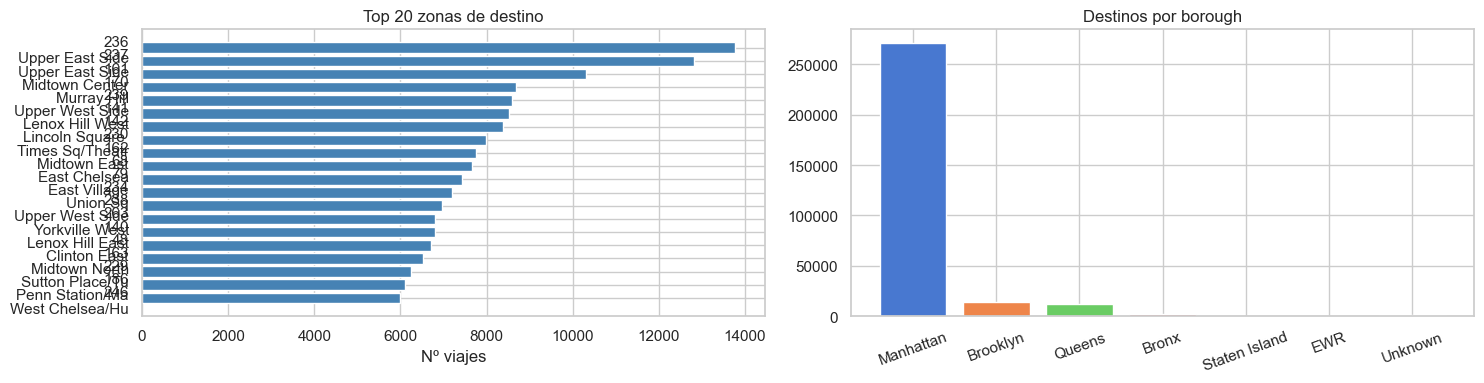


Concentración: top-1 zona = 4.6% de los viajes
Las 20 zonas más frecuentes cubren el 53.7% del total


In [21]:
# Top 20 zonas de destino
top20 = df[TARGET].value_counts().head(20)
top20_names = [f"{loc}\n{zone_lookup.loc[loc,'Zone'][:15] if loc in zone_lookup.index else ''}"
               for loc in top20.index]

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].barh(top20_names[::-1], top20.values[::-1], color='steelblue')
axes[0].set_title('Top 20 zonas de destino')
axes[0].set_xlabel('Nº viajes')

# Distribución por borough de destino
borough_dist = df['DO_Borough_id'].value_counts().sort_index()
BOROUGH_NAMES = {0:'Manhattan',1:'Brooklyn',2:'Queens',3:'Bronx',4:'Staten Island',5:'EWR',6:'Unknown'}
blabels = [BOROUGH_NAMES.get(i, str(i)) for i in borough_dist.index]
axes[1].bar(blabels, borough_dist.values, color=sns.color_palette('muted', len(borough_dist)))
axes[1].set_title('Destinos por borough')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout(); plt.show()
print(f'\nConcentración: top-1 zona = {top20.iloc[0]/len(df)*100:.1f}% de los viajes')
print(f'Las 20 zonas más frecuentes cubren el {top20.sum()/len(df)*100:.1f}% del total')

## 3. Split y preprocesamiento

In [ ]:
# Copias para cada variante
df_onehot = df.copy()
df_emb    = df.copy()
df_ae     = df.copy()

y = df['do_zone_idx'].values

idx = np.arange(len(df))
tv_idx, test_idx = train_test_split(idx, test_size=0.15,
                                     stratify=y, random_state=SEED)
train_idx, val_idx = train_test_split(tv_idx, test_size=0.1765,
                                       stratify=y[tv_idx], random_state=SEED)

print(f'Train: {len(train_idx):,} | Val: {len(val_idx):,} | Test: {len(test_idx):,}')

### 3.1 Preprocesamiento MLP base (one-hot)

In [ ]:
df_onehot_enc = pd.get_dummies(df_onehot, columns=CAT_ONEHOT, drop_first=False)
onehot_cols = [c for c in df_onehot_enc.columns
               if any(c.startswith(p+'_') for p in CAT_ONEHOT)]

features_base = NUM_FEATS + onehot_cols
X_base = df_onehot_enc[features_base].astype(np.float32).values
y_base = df_onehot_enc['do_zone_idx'].values

scaler_base = StandardScaler()
X_base[train_idx] = scaler_base.fit_transform(X_base[train_idx])
X_base[val_idx]   = scaler_base.transform(X_base[val_idx])
X_base[test_idx]  = scaler_base.transform(X_base[test_idx])

print(f'Features baseline: {X_base.shape[1]} | Clases: {N_CLASSES}')

### 3.2 DataLoaders baseline

In [ ]:
BATCH_SIZE = 256

def make_loader(X, y, idx, shuffle=True):
    Xt = torch.tensor(X[idx], dtype=torch.float32)
    yt = torch.tensor(y[idx], dtype=torch.long)
    return DataLoader(TensorDataset(Xt, yt), batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader_base = make_loader(X_base, y_base, train_idx)
val_loader_base   = make_loader(X_base, y_base, val_idx,   shuffle=False)
test_loader_base  = make_loader(X_base, y_base, test_idx,  shuffle=False)

xb, yb = next(iter(train_loader_base))
print('Batch X:', xb.shape, '| Batch y:', yb.shape)

## 4. MLP Base (sin embeddings)

Variables categóricas de baja cardinalidad (VendorID, RatecodeID, PU_Borough_id) con one-hot.  
PULocationID se excluye aquí para no agregar 265 dimensiones — entra como embedding en la sección 5.  
Con 265 clases de destino, la métrica principal es **Top-5 Accuracy** además de la accuracy estándar.

In [ ]:
class MLPBase(nn.Module):
    def __init__(self, input_dim, hidden_dims=(256, 128, 64), dropout=0.3, n_classes=265):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model_base = MLPBase(input_dim=X_base.shape[1], n_classes=N_CLASSES).to(DEVICE)
print(model_base)
print(f'Parametros: {sum(p.numel() for p in model_base.parameters()):,}')

In [ ]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * len(yb)
        correct += (logits.argmax(1) == yb).sum().item()
        total += len(yb)
    return total_loss / total, correct / total

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        logits = model(Xb)
        loss = criterion(logits, yb)
        total_loss += loss.item() * len(yb)
        correct += (logits.argmax(1) == yb).sum().item()
        total += len(yb)
    return total_loss / total, correct / total

@torch.no_grad()
def get_preds(model, loader):
    model.eval()
    y_true, y_pred, y_scores = [], [], []
    for Xb, yb in loader:
        logits = model(Xb.to(DEVICE))
        y_scores.append(torch.softmax(logits, dim=1).cpu().numpy())
        y_pred.extend(logits.argmax(1).cpu().numpy())
        y_true.extend(yb.numpy())
    return np.array(y_true), np.array(y_pred), np.vstack(y_scores)

def plot_curves(train_vals, val_vals, metric='Loss', title=''):
    plt.figure(figsize=(8, 4))
    plt.plot(train_vals, label='Train')
    plt.plot(val_vals,   label='Validacion')
    plt.xlabel('Epoca'); plt.ylabel(metric)
    plt.title(title or metric); plt.legend(); plt.tight_layout(); plt.show()

def eval_report(y_true, y_pred, y_scores, label=''):
    acc   = accuracy_score(y_true, y_pred)
    bacc  = balanced_accuracy_score(y_true, y_pred)
    top5  = top_k_accuracy_score(y_true, y_scores, k=5)
    top10 = top_k_accuracy_score(y_true, y_scores, k=10)
    print(f'=== {label} ===')
    print(f'  Accuracy:          {acc:.4f}')
    print(f'  Balanced Accuracy: {bacc:.4f}')
    print(f'  Top-5  Accuracy:   {top5:.4f}')
    print(f'  Top-10 Accuracy:   {top10:.4f}')
    return {'acc': acc, 'bacc': bacc, 'top5': top5, 'top10': top10}

In [ ]:
EPOCHS    = 60
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_base.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

hist_base = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(1, EPOCHS + 1):
    tl, ta = train_epoch(model_base, train_loader_base, criterion, optimizer)
    vl, va = eval_epoch(model_base,  val_loader_base,   criterion)
    scheduler.step()
    hist_base['train_loss'].append(tl); hist_base['val_loss'].append(vl)
    hist_base['train_acc'].append(ta);  hist_base['val_acc'].append(va)
    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:03d} | loss={tl:.4f} acc={ta:.3f} | val_loss={vl:.4f} val_acc={va:.3f}')

In [ ]:
plot_curves(hist_base['train_loss'], hist_base['val_loss'], 'Cross-Entropy Loss', 'MLP Base')
plot_curves(hist_base['train_acc'],  hist_base['val_acc'],  'Accuracy',            'MLP Base')

In [ ]:
y_true_base, y_pred_base, y_scores_base = get_preds(model_base, test_loader_base)
metrics_base = eval_report(y_true_base, y_pred_base, y_scores_base, 'MLP Base (test)')

# Top zonas mas confundidas
from collections import Counter
errors = [(y_true_base[i]+1, y_pred_base[i]+1)
          for i in range(len(y_true_base)) if y_true_base[i] != y_pred_base[i]]
top_errors = Counter(errors).most_common(10)
print('\nTop 10 pares (real, predicho) mas confundidos:')
for (real, pred), cnt in top_errors:
    rname = zone_lookup.loc[real,'Zone'] if real in zone_lookup.index else real
    pname = zone_lookup.loc[pred,'Zone'] if pred in zone_lookup.index else pred
    print(f'  {rname} -> {pname}: {cnt} veces')

## 5. MLP con Embeddings

Con 265 zonas de destino, la zona de origen (`PULocationID`) es la señal geoespacial más informativa.  
El embedding le permite al modelo aprender que zonas geográficamente cercanas son similares en comportamiento,  
sin necesitar 265 dimensiones one-hot.

In [ ]:
# Remap PULocationID a 0-based
for col, n_cats in CAT_FEATS_EMB.items():
    df_emb[col] = df_emb[col].clip(0, n_cats - 1).astype(np.int64)
df_emb['PULocationID'] = (df_emb['PULocationID'] - 1).clip(0, 264).astype(np.int64)

NUM_BINARY = NUM_FEATS  # ya incluye binarias y ordinales
X_num_emb = df_emb[NUM_BINARY].astype(np.float32).values
X_cat_emb = df_emb[list(CAT_FEATS_EMB.keys())].astype(np.int64).values
y_emb     = df_emb['do_zone_idx'].values

scaler_emb = StandardScaler()
X_num_emb[train_idx] = scaler_emb.fit_transform(X_num_emb[train_idx])
X_num_emb[val_idx]   = scaler_emb.transform(X_num_emb[val_idx])
X_num_emb[test_idx]  = scaler_emb.transform(X_num_emb[test_idx])

print(f'X_num: {X_num_emb.shape} | X_cat: {X_cat_emb.shape}')

In [ ]:
class EmbDataset(Dataset):
    def __init__(self, X_num, X_cat, y, idx):
        self.X_num = torch.tensor(X_num[idx], dtype=torch.float32)
        self.X_cat = torch.tensor(X_cat[idx], dtype=torch.long)
        self.y     = torch.tensor(y[idx],     dtype=torch.long)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X_num[i], self.X_cat[i], self.y[i]

train_ds_emb = EmbDataset(X_num_emb, X_cat_emb, y_emb, train_idx)
val_ds_emb   = EmbDataset(X_num_emb, X_cat_emb, y_emb, val_idx)
test_ds_emb  = EmbDataset(X_num_emb, X_cat_emb, y_emb, test_idx)

train_loader_emb = DataLoader(train_ds_emb, batch_size=BATCH_SIZE, shuffle=True)
val_loader_emb   = DataLoader(val_ds_emb,   batch_size=512, shuffle=False)
test_loader_emb  = DataLoader(test_ds_emb,  batch_size=512, shuffle=False)

In [ ]:
# Regla de dedo para dimension de embedding
def emb_dim(n_cats):
    return min(50, (n_cats + 1) // 2)

class MLPWithEmb(nn.Module):
    def __init__(self, num_dim, cat_vocab, hidden_dims=(256,128,64), dropout=0.3, n_classes=265):
        super().__init__()
        self.embs = nn.ModuleList([nn.Embedding(n, emb_dim(n)) for n in cat_vocab])
        total_emb = sum(emb_dim(n) for n in cat_vocab)
        layers = []
        prev = num_dim + total_emb
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x_num, x_cat):
        emb_out = [emb(x_cat[:, i]) for i, emb in enumerate(self.embs)]
        x = torch.cat([x_num] + emb_out, dim=1)
        return self.net(x)

cat_vocabs = list(CAT_FEATS_EMB.values())
model_emb = MLPWithEmb(num_dim=X_num_emb.shape[1], cat_vocab=cat_vocabs,
                        n_classes=N_CLASSES).to(DEVICE)
print(model_emb)
print(f'Parametros: {sum(p.numel() for p in model_emb.parameters()):,}')

In [ ]:
def train_epoch_emb(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for xn, xc, yb in loader:
        xn, xc, yb = xn.to(DEVICE), xc.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xn, xc)
        loss = criterion(logits, yb)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * len(yb)
        correct += (logits.argmax(1) == yb).sum().item()
        total += len(yb)
    return total_loss / total, correct / total

@torch.no_grad()
def eval_epoch_emb(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for xn, xc, yb in loader:
        xn, xc, yb = xn.to(DEVICE), xc.to(DEVICE), yb.to(DEVICE)
        logits = model(xn, xc)
        loss = criterion(logits, yb)
        total_loss += loss.item() * len(yb)
        correct += (logits.argmax(1) == yb).sum().item()
        total += len(yb)
    return total_loss / total, correct / total

@torch.no_grad()
def get_preds_emb(model, loader):
    model.eval()
    y_true, y_pred, y_scores = [], [], []
    for xn, xc, yb in loader:
        logits = model(xn.to(DEVICE), xc.to(DEVICE))
        y_scores.append(torch.softmax(logits, dim=1).cpu().numpy())
        y_pred.extend(logits.argmax(1).cpu().numpy())
        y_true.extend(yb.numpy())
    return np.array(y_true), np.array(y_pred), np.vstack(y_scores)

In [ ]:
EPOCHS_EMB    = 60
optimizer_emb = optim.Adam(model_emb.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_emb = optim.lr_scheduler.StepLR(optimizer_emb, step_size=20, gamma=0.5)

hist_emb = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(1, EPOCHS_EMB + 1):
    tl, ta = train_epoch_emb(model_emb, train_loader_emb, criterion, optimizer_emb)
    vl, va = eval_epoch_emb(model_emb, val_loader_emb, criterion)
    scheduler_emb.step()
    hist_emb['train_loss'].append(tl); hist_emb['val_loss'].append(vl)
    hist_emb['train_acc'].append(ta);  hist_emb['val_acc'].append(va)
    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:03d} | loss={tl:.4f} acc={ta:.3f} | val_loss={vl:.4f} val_acc={va:.3f}')

In [ ]:
plot_curves(hist_emb['train_loss'], hist_emb['val_loss'], 'Cross-Entropy Loss', 'MLP Embeddings')
plot_curves(hist_emb['train_acc'],  hist_emb['val_acc'],  'Accuracy',            'MLP Embeddings')

In [ ]:
y_true_emb, y_pred_emb, y_scores_emb = get_preds_emb(model_emb, test_loader_emb)
metrics_emb = eval_report(y_true_emb, y_pred_emb, y_scores_emb, 'MLP Embeddings (test)')

### 5.1 Visualización del espacio de embeddings de PULocationID

In [ ]:
from sklearn.decomposition import PCA

pu_weights = model_emb.embs[0].weight.data.cpu().numpy()  # (265, emb_dim)
pca = PCA(n_components=2, random_state=SEED)
pu_2d = pca.fit_transform(pu_weights)

BOROUGH_MAP_COL = {'Manhattan': 0, 'Brooklyn': 1, 'Queens': 2,
                    'Bronx': 3, 'Staten Island': 4}
BOROUGH_NAMES = {0:'Manhattan',1:'Brooklyn',2:'Queens',3:'Bronx',4:'Staten Island'}

colors = zone_lookup['Borough'].map(BOROUGH_MAP_COL).reindex(range(1, 266)).fillna(-1).values

fig, ax = plt.subplots(figsize=(9, 7))
palette = sns.color_palette('muted', 5)
for bid, bname in BOROUGH_NAMES.items():
    mask = colors == bid
    ax.scatter(pu_2d[mask, 0], pu_2d[mask, 1], label=bname,
               color=palette[bid], alpha=0.75, s=45)

ax.set_title('PCA del embedding de PULocationID (265 zonas)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(title='Borough de origen')
plt.tight_layout(); plt.show()

## 6. Análisis de sobreajuste y regularización

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(hist_base['train_loss'], label='Base train', lw=1.5)
axes[0].plot(hist_base['val_loss'],   label='Base val',   lw=1.5, ls='--')
axes[0].plot(hist_emb['train_loss'],  label='Emb train',  lw=1.5)
axes[0].plot(hist_emb['val_loss'],    label='Emb val',    lw=1.5, ls='--')
axes[0].set_title('Cross-Entropy Loss'); axes[0].set_xlabel('Epoca'); axes[0].legend()

axes[1].plot(hist_base['train_acc'], label='Base train', lw=1.5)
axes[1].plot(hist_base['val_acc'],   label='Base val',   lw=1.5, ls='--')
axes[1].plot(hist_emb['train_acc'],  label='Emb train',  lw=1.5)
axes[1].plot(hist_emb['val_acc'],    label='Emb val',    lw=1.5, ls='--')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoca'); axes[1].legend()

plt.suptitle('Comparacion train/val — Base vs Embeddings')
plt.tight_layout(); plt.show()

# TODO (Actividad 4):
# - Analizar si existe sobreajuste (brecha creciente train/val)
# - Implementar al menos una tecnica adicional: mayor dropout, early stopping, weight decay
# - Reportar efecto en val y test

## 7. AutoEncoder + MLP

In [ ]:
# TODO (Actividad 5)
#
# Pasos:
#   1. Entrenar AE sobre las variables numericas → reconstruccion con MSELoss
#   2. Congelar encoder → usar bottleneck como entrada a MLPBase(input_dim=bottleneck)
#   3. Comparar metricas contra secciones 4 y 5
#
# Arquitectura sugerida (basada en Taller_T1 seccion 5):
#
# class AutoEncoder(nn.Module):
#     def __init__(self, input_dim, hidden=[128,64], bottleneck=32, dropout=0.2):
#         super().__init__()
#         enc, dec, prev = [], [], input_dim
#         for h in hidden:
#             enc += [nn.Linear(prev,h), nn.ReLU(), nn.Dropout(dropout)]; prev=h
#         enc.append(nn.Linear(prev, bottleneck))
#         self.encoder = nn.Sequential(*enc)
#         prev = bottleneck
#         for h in reversed(hidden):
#             dec += [nn.Linear(prev,h), nn.ReLU(), nn.Dropout(dropout)]; prev=h
#         dec.append(nn.Linear(prev, input_dim))
#         self.decoder = nn.Sequential(*dec)
#     def forward(self, x):
#         z = self.encoder(x)
#         return self.decoder(z), z

print('Pendiente — Actividad 5')

## 8. Análisis crítico final

In [ ]:
results = pd.DataFrame({
    'Modelo':         ['MLP Base', 'MLP Embeddings', 'AE + MLP'],
    'Accuracy':       [metrics_base['acc'],  metrics_emb['acc'],  None],
    'Balanced Acc':   [metrics_base['bacc'], metrics_emb['bacc'], None],
    'Top-5 Acc':      [metrics_base['top5'], metrics_emb['top5'], None],
    'Top-10 Acc':     [metrics_base['top10'],metrics_emb['top10'],None],
}).set_index('Modelo')
results.round(4)

### Puntos a desarrollar:

1. **Dificultad del problema**: con 265 clases y distribución muy desbalanceada (Manhattan concentra >50% de destinos), la accuracy cruda puede ser engañosa — analizar Top-K Accuracy y Balanced Accuracy.
2. **MLP base vs embeddings**: ¿el embedding de PULocationID mejoró la predicción? ¿Para qué zonas fue más útil?
3. **Visualización de embeddings**: ¿zonas del mismo borough quedan agrupadas en el espacio PCA? ¿Hay estructura geográfica emergente?
4. **Sobreajuste**: con 265 clases y 300k filas (~1.1k ejemplos promedio por clase), el riesgo de sobreajuste en clases raras es alto.
5. **AutoEncoder**: ¿el bottleneck comprime información útil para clasificación, o pierde señal importante?